# Chapter 11: The Golden Section and Phyllotaxis

Source span inspected: printed pp. 160-174, PDF pp. 178-192. The assigned scan covers the golden section in a pentagon, Euclid's segment-extension construction, Pacioli's golden rectangles and the icosahedron connection, the golden spiral, Fibonacci and Lucas identities, and the cylinder-strip model of phyllotaxis. PDF pp. 191-192 are transition/blank pages after the chapter.

## Chapter Goal

The goal is to make one number, \(\tau=(1+\sqrt5)/2\), do visible geometric work. By the end of the notebook, you should be able to recognize the same invariant in four settings: a divided segment, a regular pentagon and pentagram, a logarithmic spiral generated by quarter-turn similarity, and phyllotactic point patterns whose best visible rows are Fibonacci offsets.

## Computational Translation Guide

- A golden section is represented by measured lengths \((\text{larger}/\text{smaller})=(\text{whole}/\text{larger})=\tau\), plus the exact symbolic identity \(\tau^2-\tau-1=0\).
- A pentagon is represented by coordinates, so diagonal-to-side and diagonal-splitting ratios can be checked rather than trusted by eye.
- A golden spiral is represented by a similarity \(z\mapsto i\tau z\) or its inverse: every step rotates by a quarter turn and rescales by \(\tau\).
- Fibonacci approximants are represented as continued-fraction convergents and as integer identities, including Cassini/Simson and Lucas-number checks.
- Phyllotaxis is represented twice: first as disk points with divergence angle \(360/\tau^2\), then as the chapter's unrolled-cylinder lattice \((\{n\tau\},nh)\), where Fibonacci offsets become the shortest visible rows.

In [1]:
from pathlib import Path
import sys, math
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Polygon, Rectangle
from matplotlib.collections import LineCollection
import plotly.graph_objects as go
from scipy.spatial import Voronoi
from IPython.display import Markdown, display

CHAPTER_NO = 11
HERE = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, book_relative, display_artifact, ensure_chapter_artifact_dirs, write_csv, write_json
from utils.course import chapter_by_no

chapter = chapter_by_no(CHAPTER_NO)
ARTIFACT_DIRS = ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)
TAU = (1 + 5**0.5) / 2
GOLDEN_TURN = 1 / TAU**2
GOLDEN_ANGLE_DEG = 360 * GOLDEN_TURN
artifact_paths = []

plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 180, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10})

def remember(path):
    path = Path(path)
    artifact_paths.append(path)
    return path

def rel(path):
    return book_relative(path, BOOK_ROOT)

def save_current_figure(path, *, tight=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight" if tight else None)
    plt.close()
    return remember(path)

source_span = {
    "chapter": CHAPTER_NO,
    "title": chapter["title"],
    "printed_pages": "160-174",
    "pdf_pages": "178-192",
    "source_map_note": "Body printed pages map to PDF pages by pdf_page = printed_page + 18; pp. 191-192 are post-chapter transition/blank pages.",
    "orientation_topics": [
        "extreme and mean ratio",
        "regular pentagon and pentagram diagonal ratios",
        "Euclidean extension of a segment to golden length",
        "golden rectangle and icosahedron coordinates",
        "golden/logarithmic spiral",
        "Fibonacci and Lucas identities",
        "phyllotaxis, divergence angle, and cylinder-strip lattice rows",
    ],
}
source_path = remember(write_json(ARTIFACT_DIRS["checks"] / "source-span.json", source_span))

storyboard = {
    "chapter_goal": "Track tau through segment construction, pentagon geometry, spirals, Fibonacci approximants, and phyllotactic lattices.",
    "visual_sequence": [
        {"concept": "golden section construction", "artifact": "figures/golden-section-construction.png", "check": "larger/smaller and whole/larger both equal tau"},
        {"concept": "pentagon and pentagram ratios", "artifact": "figures/pentagon-pentagram-ratios.png", "check": "diagonal/side and diagonal split ratios equal tau"},
        {"concept": "quarter-turn logarithmic spiral", "artifact": "figures/golden-logarithmic-spiral.png and html/golden-spiral-quarter-turn.html", "check": "successive polar points rotate pi/2 and rescale by tau"},
        {"concept": "Fibonacci approximants", "artifact": "figures/fibonacci-convergence-continued-fraction.png", "check": "recurrences, Lucas identities, Cassini/Simson, Binet formula"},
        {"concept": "divergence angle", "artifact": "figures/phyllotaxis-divergence-comparison.png and html/phyllotaxis-divergence-lab.html", "check": "Fibonacci steps are best angular returns"},
        {"concept": "cylinder-strip phyllotaxis", "artifact": "figures/phyllotaxis-cylinder-strip-parastichies.png", "check": "nearest offsets for standard h are 5, 8, 13"},
    ],
    "library_routing": {
        "Matplotlib": "durable 2D construction, pentagon, spiral, convergence, and lattice diagrams",
        "Plotly": "standalone HTML inspection for spiral and divergence-parameter lab",
        "SymPy": "exact tau and trigonometric identities",
        "SciPy Voronoi": "Dirichlet-cell context for the unrolled phyllotaxis lattice",
        "NumPy/Pandas": "numeric sequences, residuals, CSV tables, and artifact manifests",
    },
}
storyboard_path = remember(write_json(ARTIFACT_DIRS["checks"] / "visual-storyboard.json", storyboard))

display(Markdown(f"Loaded **{chapter['title']}**. Artifact root: `{rel(BOOK_ROOT / 'artifacts' / 'chapter-11')}`."))

Loaded **The Golden Section and Phyllotaxis**. Artifact root: `artifacts/chapter-11`.

## 1. Extreme and Mean Ratio as a Construction

The golden section is not just the number \(1.618\ldots\). It is a rule for dividing a segment: if \(QS\) is the whole segment, \(QU\) is the larger part, and \(US\) is the smaller part, then the same ratio appears twice:

\[
\frac{QU}{US}=\frac{QS}{QU}=\tau.
\]

The construction below starts from a unit segment \(QU\), builds a square on it, marks the midpoint of \(QU\), and swings the diagonal from that midpoint back to the line. The inspection target is the endpoint \(S\): the added piece \(US\) must be exactly \(1/\tau\), so the whole length is \(\tau\).

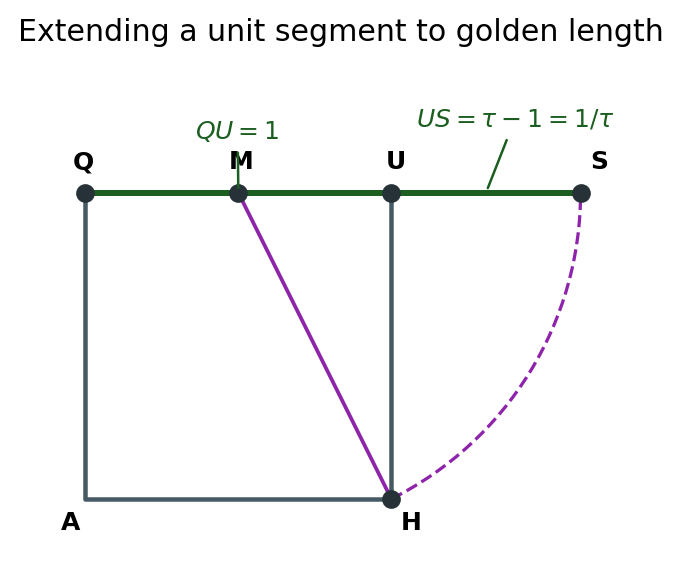

Check file: `artifacts/chapter-11/checks/golden-section-construction-checks.json`

{'tau': 1.618033988749895,
 'QS': 1.618033988749895,
 'QU': 1.0,
 'US': 0.6180339887498949,
 'larger_to_smaller': 1.6180339887498947,
 'whole_to_larger': 1.618033988749895,
 'tau_quadratic_residual': 0.0,
 'midpoint_diagonal_length': 1.118033988749895,
 'arc_endpoint_residual': 0.0}

In [2]:
Q = np.array([0.0, 0.0])
U = np.array([1.0, 0.0])
A = np.array([0.0, -1.0])
H = np.array([1.0, -1.0])
M = np.array([0.5, 0.0])
S = np.array([TAU, 0.0])
radius = np.linalg.norm(H - M)

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.plot([Q[0], U[0], H[0], A[0], Q[0]], [Q[1], U[1], H[1], A[1], Q[1]], color="#455a64", lw=1.8)
ax.plot([M[0], H[0]], [M[1], H[1]], color="#8e24aa", lw=1.5, label=r"$MH=\sqrt5/2$")
ax.plot([Q[0], S[0]], [0, 0], color="#1b5e20", lw=2.4)
ax.scatter([Q[0], U[0], M[0], H[0], S[0]], [Q[1], U[1], M[1], H[1], S[1]], s=42, zorder=3, color="#263238")
for name, point, offset in [("Q", Q, (-0.04, 0.08)), ("U", U, (-0.02, 0.08)), ("M", M, (-0.03, 0.08)), ("H", H, (0.03, -0.10)), ("S", S, (0.03, 0.08)), ("A", A, (-0.08, -0.10))]:
    ax.text(point[0] + offset[0], point[1] + offset[1], name, weight="bold")
ax.add_patch(Arc(M, 2*radius, 2*radius, theta1=-63.435, theta2=0, color="#8e24aa", lw=1.3, linestyle="--"))
ax.annotate(r"$QU=1$", xy=(0.50, 0), xytext=(0.36, 0.18), arrowprops={"arrowstyle": "-", "color": "#1b5e20"}, color="#1b5e20")
ax.annotate(r"$US=\tau-1=1/\tau$", xy=((1+TAU)/2, 0), xytext=(1.08, 0.22), arrowprops={"arrowstyle": "-", "color": "#1b5e20"}, color="#1b5e20")
ax.set_title("Extending a unit segment to golden length")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.15, 1.82)
ax.set_ylim(-1.18, 0.45)
ax.axis("off")
construction_path = save_current_figure(ARTIFACT_DIRS["figures"] / "golden-section-construction.png")

construction_checks = {
    "tau": TAU,
    "QS": float(np.linalg.norm(S - Q)),
    "QU": float(np.linalg.norm(U - Q)),
    "US": float(np.linalg.norm(S - U)),
    "larger_to_smaller": float(np.linalg.norm(U - Q) / np.linalg.norm(S - U)),
    "whole_to_larger": float(np.linalg.norm(S - Q) / np.linalg.norm(U - Q)),
    "tau_quadratic_residual": float(TAU**2 - TAU - 1),
    "midpoint_diagonal_length": float(radius),
    "arc_endpoint_residual": float(abs((M[0] + radius) - S[0])),
}
construction_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "golden-section-construction-checks.json", construction_checks))
assert abs(construction_checks["larger_to_smaller"] - TAU) < 1e-12
assert abs(construction_checks["whole_to_larger"] - TAU) < 1e-12
assert abs(construction_checks["tau_quadratic_residual"]) < 1e-12
display_artifact(construction_path, width=760)
display(Markdown(f"Check file: `{rel(construction_check_path)}`"))
construction_checks

## 2. Pentagon and Pentagram Relations

In a regular pentagon, the golden ratio appears before any spiral or plant model enters the story. If the side length is normalized to 1, every diagonal has length \(\tau\). When two diagonals cross, each diagonal is split into a unit-length larger piece and a shorter piece \(1/\tau\).

The figure computes these statements from coordinates. The pentagram is included because its inner pentagon is not a separate ornament: it is the same regular-pentagon geometry repeated at a smaller scale.

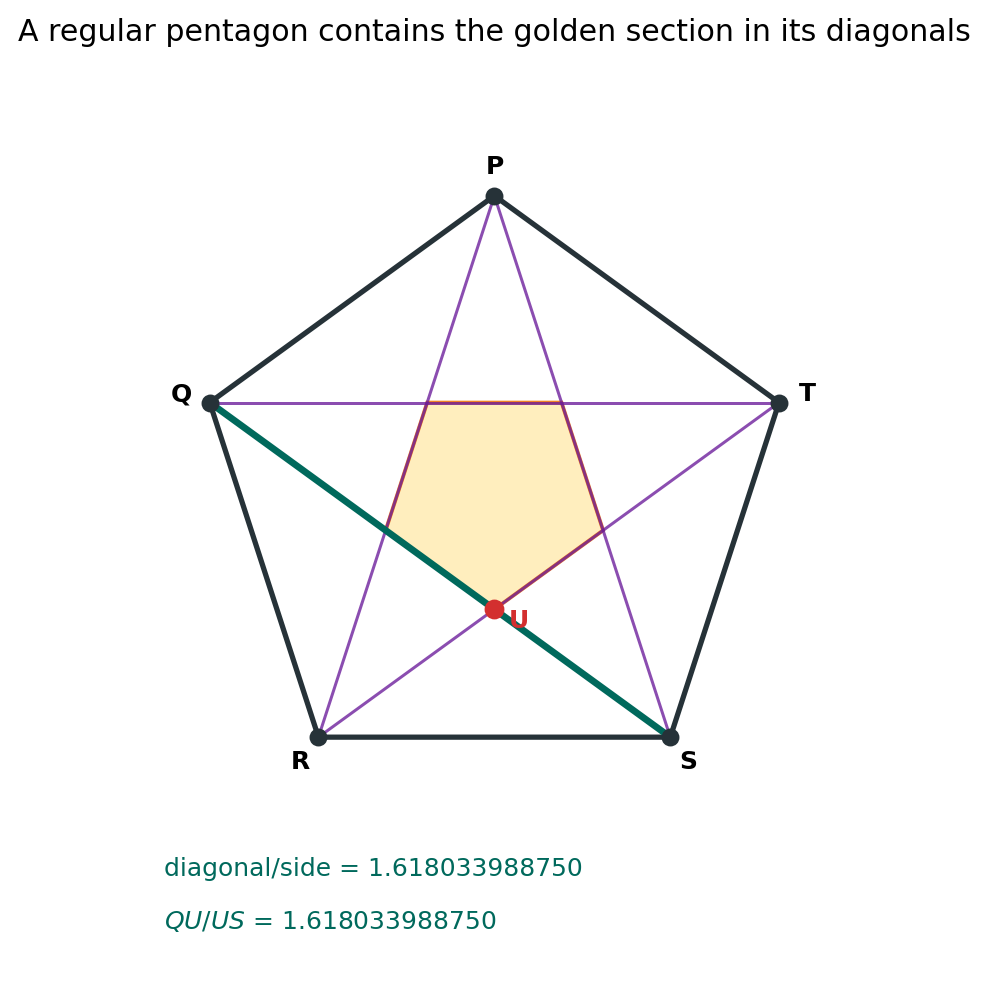

Check file: `artifacts/chapter-11/checks/pentagon-pentagram-invariants.json`

{'side_mean': 0.9999999999999998,
 'side_max_deviation': 2.220446049250313e-16,
 'diagonal_mean': 1.6180339887498945,
 'diagonal_to_side_ratio': 1.618033988749895,
 'QS': 1.6180339887498947,
 'QU': 0.9999999999999999,
 'US': 0.6180339887498947,
 'QU_to_US': 1.6180339887498951,
 'QS_to_QU': 1.618033988749895,
 'inner_pentagon_side_mean': 0.3819660112501052,
 'outer_to_inner_side_ratio': 2.618033988749894,
 'exact_2cos_pi_over_5_minus_tau': '0'}

In [3]:
def line_intersection(p1, p2, p3, p4):
    p1, p2, p3, p4 = map(lambda p: np.asarray(p, dtype=float), [p1, p2, p3, p4])
    A = np.column_stack((p2 - p1, -(p4 - p3)))
    b = p3 - p1
    t, u = np.linalg.solve(A, b)
    return p1 + t * (p2 - p1), t, u

R_circ = 1 / (2 * np.sin(np.pi / 5))
angles = np.deg2rad([90, 162, 234, 306, 18])
labels = np.array(["P", "Q", "R", "S", "T"])
V = np.column_stack([R_circ * np.cos(angles), R_circ * np.sin(angles)])
idx = {name: i for i, name in enumerate(labels)}
diagonal_pairs = [(0, 2), (1, 3), (2, 4), (3, 0), (4, 1)]
inner_points = []
for a in range(len(diagonal_pairs)):
    for b in range(a + 1, len(diagonal_pairs)):
        i, j = diagonal_pairs[a]
        k, l = diagonal_pairs[b]
        point, t, u = line_intersection(V[i], V[j], V[k], V[l])
        if 1e-8 < t < 1 - 1e-8 and 1e-8 < u < 1 - 1e-8 and not any(np.linalg.norm(point - q) < 1e-8 for q in inner_points):
            inner_points.append(point)
inner_points = np.array(sorted(inner_points, key=lambda p: np.arctan2(p[1], p[0])))
U_cross, _, _ = line_intersection(V[idx["Q"]], V[idx["S"]], V[idx["R"]], V[idx["T"]])
side_lengths = np.array([np.linalg.norm(V[(i+1)%5] - V[i]) for i in range(5)])
diag_lengths = np.array([np.linalg.norm(V[j] - V[i]) for i, j in diagonal_pairs])
QS = np.linalg.norm(V[idx["S"]] - V[idx["Q"]])
QU = np.linalg.norm(U_cross - V[idx["Q"]])
US = np.linalg.norm(V[idx["S"]] - U_cross)
inner_side_lengths = np.array([np.linalg.norm(inner_points[(i+1)%5] - inner_points[i]) for i in range(5)])

fig, ax = plt.subplots(figsize=(7.0, 6.6))
ax.add_patch(Polygon(V, closed=True, fill=False, edgecolor="#263238", linewidth=2.1))
for i, j in diagonal_pairs:
    ax.plot([V[i,0], V[j,0]], [V[i,1], V[j,1]], color="#6a1b9a", lw=1.2, alpha=0.78)
ax.add_patch(Polygon(inner_points, closed=True, fill=True, facecolor="#ffecb3", edgecolor="#ef6c00", linewidth=1.5, alpha=0.85))
ax.plot([V[idx["Q"],0], V[idx["S"],0]], [V[idx["Q"],1], V[idx["S"],1]], color="#00695c", lw=2.7)
ax.scatter(V[:,0], V[:,1], s=38, color="#263238", zorder=4)
ax.scatter([U_cross[0]], [U_cross[1]], s=48, color="#d32f2f", zorder=5)
for name, point in zip(labels, V):
    ax.text(point[0]*1.10, point[1]*1.10, name, ha="center", va="center", weight="bold")
ax.text(U_cross[0] + 0.04, U_cross[1] - 0.05, "U", color="#d32f2f", weight="bold")
ax.text(-0.94, -1.08, rf"diagonal/side = {diag_lengths.mean()/side_lengths.mean():.12f}", color="#00695c")
ax.text(-0.94, -1.23, rf"$QU/US$ = {QU/US:.12f}", color="#00695c")
ax.set_title("A regular pentagon contains the golden section in its diagonals")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.35, 1.25)
ax.axis("off")
pentagon_path = save_current_figure(ARTIFACT_DIRS["figures"] / "pentagon-pentagram-ratios.png")

sympy_identity = sp.simplify(2*sp.cos(sp.pi/5) - (1 + sp.sqrt(5))/2)
pentagon_checks = {
    "side_mean": float(side_lengths.mean()),
    "side_max_deviation": float(np.max(np.abs(side_lengths - side_lengths.mean()))),
    "diagonal_mean": float(diag_lengths.mean()),
    "diagonal_to_side_ratio": float(diag_lengths.mean() / side_lengths.mean()),
    "QS": float(QS), "QU": float(QU), "US": float(US),
    "QU_to_US": float(QU / US),
    "QS_to_QU": float(QS / QU),
    "inner_pentagon_side_mean": float(inner_side_lengths.mean()),
    "outer_to_inner_side_ratio": float(side_lengths.mean() / inner_side_lengths.mean()),
    "exact_2cos_pi_over_5_minus_tau": str(sympy_identity),
}
pentagon_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "pentagon-pentagram-invariants.json", pentagon_checks))
assert abs(pentagon_checks["diagonal_to_side_ratio"] - TAU) < 1e-12
assert abs(pentagon_checks["QU_to_US"] - TAU) < 1e-12
assert abs(pentagon_checks["QS_to_QU"] - TAU) < 1e-12
assert sympy_identity == 0
display_artifact(pentagon_path, width=700)
display(Markdown(f"Check file: `{rel(pentagon_check_path)}`"))
pentagon_checks

## 3. Golden Rectangles and the Logarithmic Spiral

The identity \(\tau=1+1/\tau\) says that when a square is cut from a golden rectangle, the remaining rectangle is similar to the original one. Repeating that cut gives a nested family of golden rectangles. The cleaner computational invariant is the map between corresponding spiral points:

\[
(r,\theta)\mapsto (\tau r,\theta+\pi/2).
\]

Those points lie on the logarithmic spiral \(r=\mu^\theta\) with \(\mu=\tau^{2/\pi}\). The left panel shows the rectangle dissection; the right panel separates the exact logarithmic spiral from the common quarter-circle approximation.

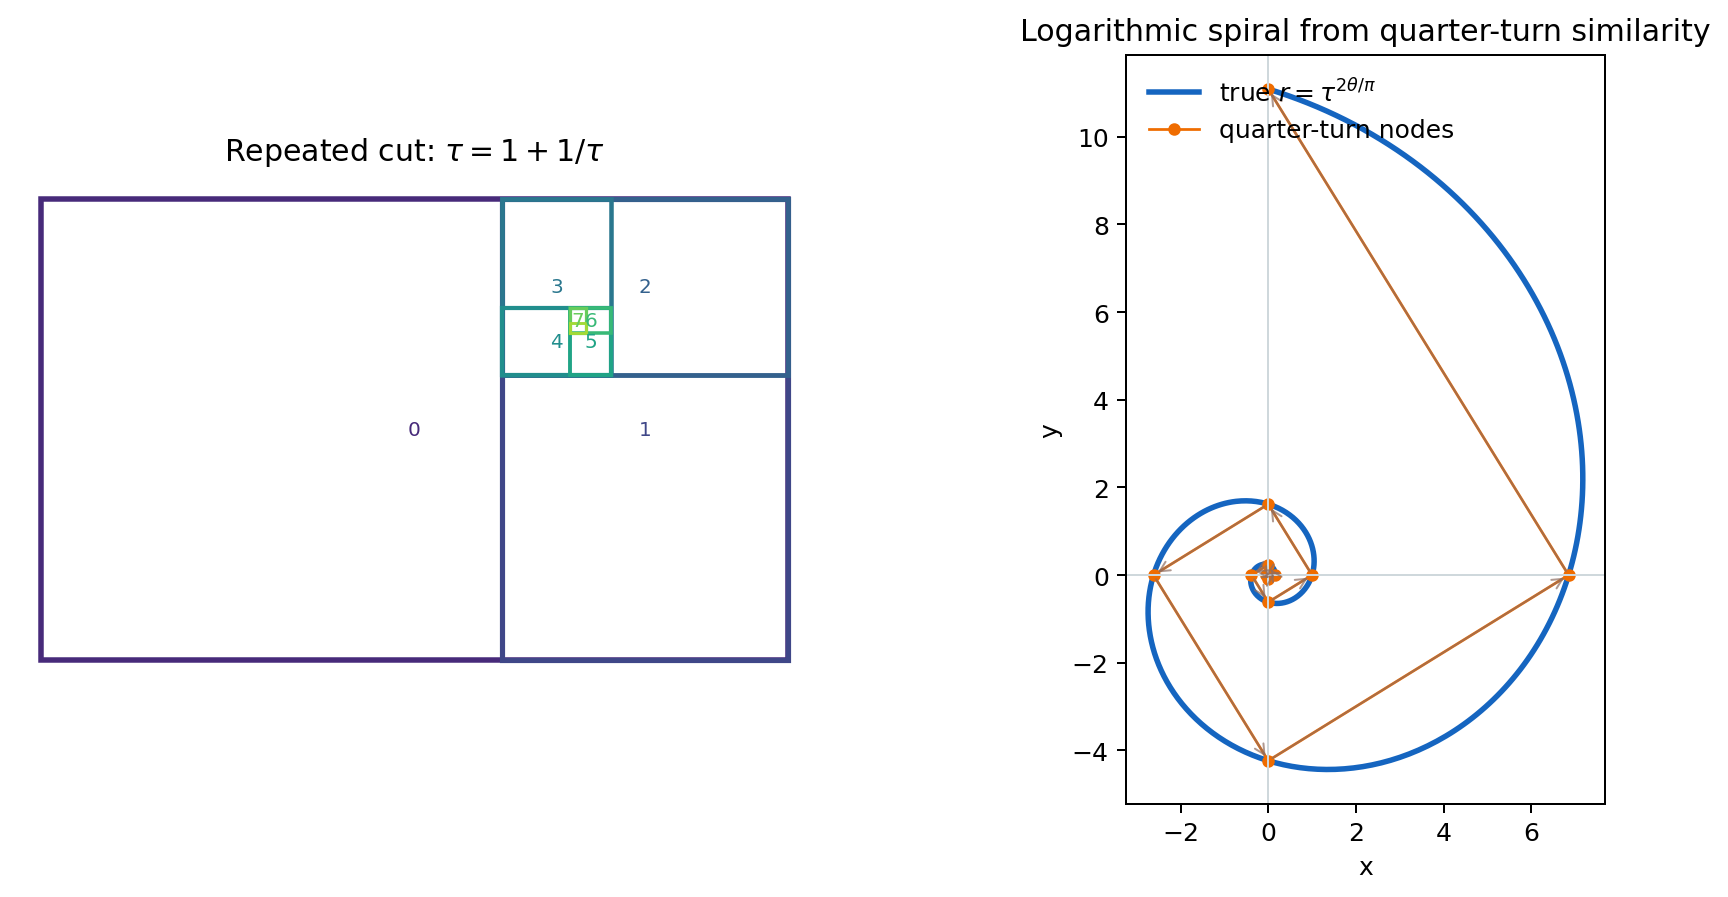

Check file: `artifacts/chapter-11/checks/golden-spiral-invariants.json`

{'mu': 1.3584562741829884,
 'node_radius_ratio_mean': 1.618033988749895,
 'node_radius_ratio_max_deviation_from_tau': 2.220446049250313e-16,
 'node_angle_step_mean': 1.5707963267948963,
 'node_angle_step_max_deviation_from_pi_over_2': 1.7763568394002505e-15,
 'log_spiral_equation_max_residual': 1.7763568394002505e-15,
 'similarity_matrix_inverse_step': [[0.0, -0.6180339887498948],
  [0.6180339887498948, 0.0]]}

In [4]:
def golden_rectangles(count=8):
    rects = []
    x, y, w, h = 0.0, 0.0, TAU, 1.0
    for i in range(count):
        rects.append((x, y, w, h))
        if w >= h:
            if i % 4 == 0:
                x = x + h
            w = w - h
        else:
            if i % 4 == 1:
                y = y + w
            h = h - w
    return rects

rects = golden_rectangles(9)
n_values = np.arange(-7, 6)
theta_nodes = n_values * np.pi / 2
r_nodes = TAU ** n_values
z_nodes = r_nodes * np.exp(1j * theta_nodes)
theta = np.linspace(theta_nodes.min(), theta_nodes.max(), 900)
mu = TAU ** (2/np.pi)
r = mu ** theta
z = r * np.exp(1j * theta)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.5, 5.4))
colors = plt.cm.viridis(np.linspace(0.12, 0.86, len(rects)))
for k, (x, y, w, h) in enumerate(rects):
    ax0.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=colors[k], linewidth=max(0.8, 2.2 - 0.13*k)))
    if k < len(rects) - 1:
        ax0.text(x + 0.5*w, y + 0.5*h, str(k), ha="center", va="center", fontsize=8, color=colors[k])
ax0.set_aspect("equal", adjustable="box")
ax0.set_title(r"Repeated cut: $\tau = 1 + 1/\tau$")
ax0.set_xlim(-0.05, TAU + 0.05)
ax0.set_ylim(-0.05, 1.05)
ax0.axis("off")

ax1.plot(z.real, z.imag, color="#1565c0", lw=2.2, label=r"true $r=\tau^{2\theta/\pi}$")
ax1.plot(z_nodes.real, z_nodes.imag, color="#ef6c00", lw=1.1, marker="o", ms=4, label="quarter-turn nodes")
for a, b in zip(z_nodes[:-1], z_nodes[1:]):
    ax1.annotate("", xy=(b.real, b.imag), xytext=(a.real, a.imag), arrowprops={"arrowstyle": "->", "color": "#8d6e63", "lw": 0.8, "alpha": 0.7})
ax1.axhline(0, color="#cfd8dc", lw=0.8)
ax1.axvline(0, color="#cfd8dc", lw=0.8)
ax1.set_aspect("equal", adjustable="box")
ax1.set_title("Logarithmic spiral from quarter-turn similarity")
ax1.legend(loc="upper left", frameon=False)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
spiral_path = save_current_figure(ARTIFACT_DIRS["figures"] / "golden-logarithmic-spiral.png")

fig_html = go.Figure()
fig_html.add_trace(go.Scatter(x=z.real, y=z.imag, mode="lines", name="true logarithmic spiral", line={"color": "#1565c0", "width": 3}))
fig_html.add_trace(go.Scatter(x=z_nodes.real, y=z_nodes.imag, mode="markers+lines", name="quarter-turn nodes", marker={"color": "#ef6c00", "size": 8}))
fig_html.update_layout(title="Golden spiral: highlighted points rotate 90 degrees and rescale by tau", xaxis={"scaleanchor": "y", "title": "x"}, yaxis={"title": "y"}, template="plotly_white", width=760, height=620)
spiral_html_path = ARTIFACT_DIRS["html"] / "golden-spiral-quarter-turn.html"
fig_html.write_html(spiral_html_path, include_plotlyjs="cdn")
remember(spiral_html_path)

radius_ratios = np.abs(z_nodes[1:]) / np.abs(z_nodes[:-1])
angle_steps = np.diff(np.unwrap(np.angle(z_nodes)))
spiral_checks = {
    "mu": float(mu),
    "node_radius_ratio_mean": float(radius_ratios.mean()),
    "node_radius_ratio_max_deviation_from_tau": float(np.max(np.abs(radius_ratios - TAU))),
    "node_angle_step_mean": float(angle_steps.mean()),
    "node_angle_step_max_deviation_from_pi_over_2": float(np.max(np.abs(angle_steps - np.pi/2))),
    "log_spiral_equation_max_residual": float(np.max(np.abs(np.abs(z) - mu**theta))),
    "similarity_matrix_inverse_step": [[0.0, -1/TAU], [1/TAU, 0.0]],
}
spiral_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "golden-spiral-invariants.json", spiral_checks))
assert spiral_checks["node_radius_ratio_max_deviation_from_tau"] < 1e-12
assert spiral_checks["node_angle_step_max_deviation_from_pi_over_2"] < 1e-12
assert spiral_checks["log_spiral_equation_max_residual"] < 1e-12
display_artifact(spiral_path, width=880)
display_artifact(spiral_html_path, width=760)
display(Markdown(f"Check file: `{rel(spiral_check_path)}`"))
spiral_checks

## 4. Fibonacci Approximants and Exact Identities

The continued fraction for \(\tau\) has only 1s, so its convergents are ratios of consecutive Fibonacci numbers. This makes \(\tau\) the slowest-converging irrational in a precise continued-fraction sense: every approximant improves, but no large partial quotient suddenly gives an exceptionally accurate rational.

The table and plot track two things at once: the visible convergence of \(F_{n+1}/F_n\), and the integer identities that explain why the same sequence keeps reappearing in the geometry.

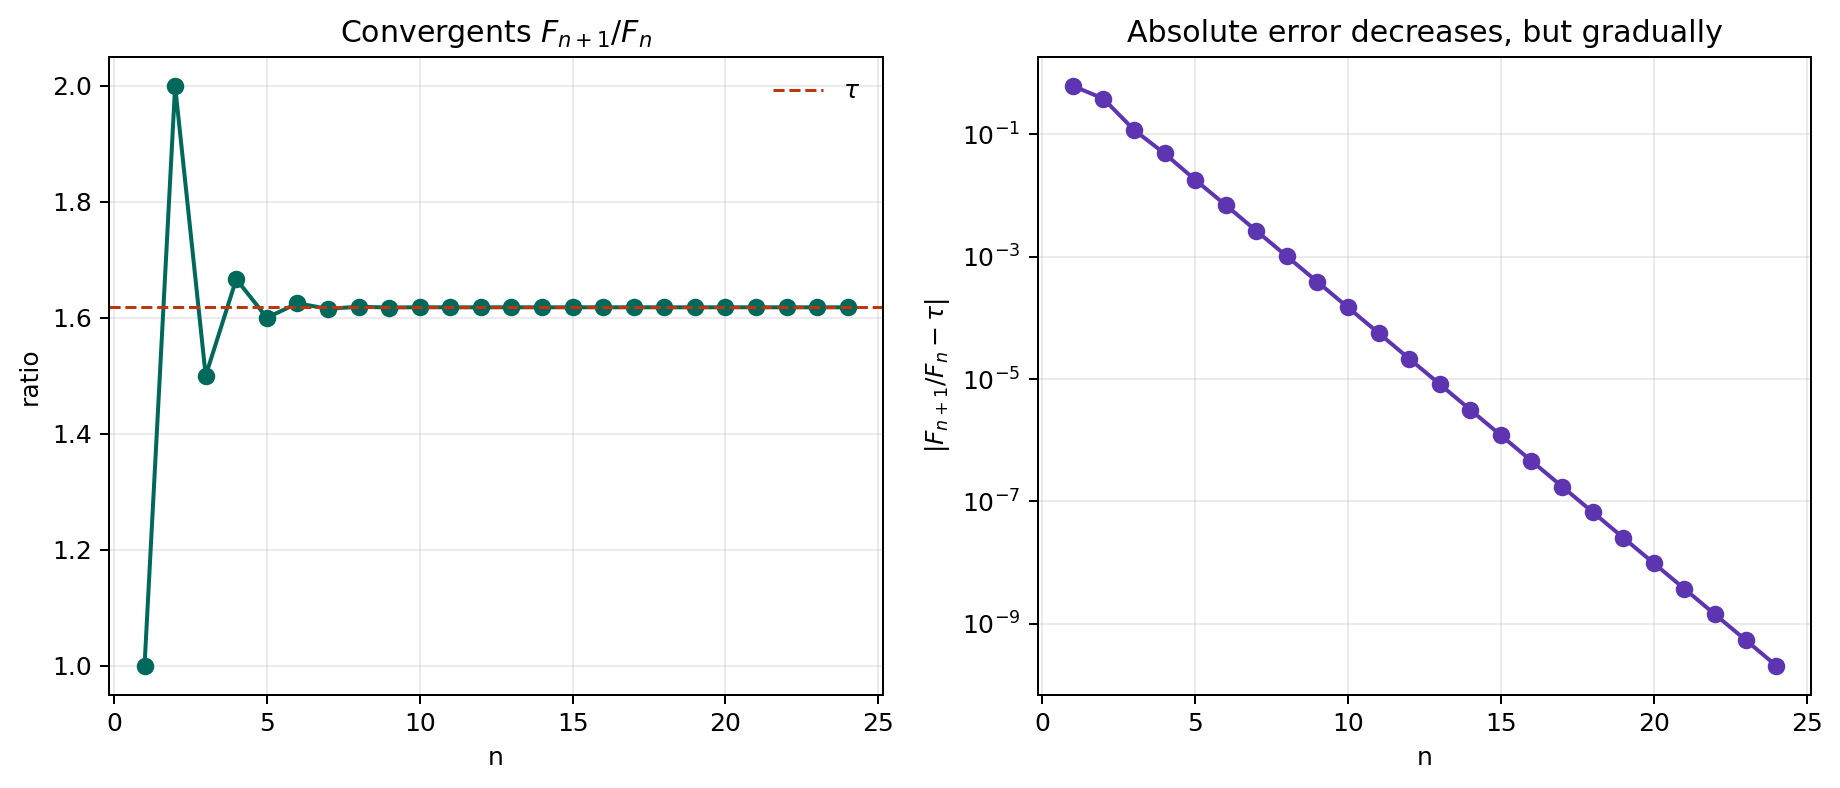

Approximant table: `artifacts/chapter-11/tables/fibonacci-approximants.csv`  

Check file: `artifacts/chapter-11/checks/fibonacci-lucas-identities.json`

,n,F_n,F_n_plus_1,ratio_F_next_over_F,error_from_tau,abs_error,continued_fraction_convergent
0,1,1,1,1.000000,-0.618034,0.618034,1/1
1,2,1,2,2.000000,0.381966,0.381966,2/1
2,3,2,3,1.500000,-0.118034,0.118034,3/2
3,4,3,5,1.666667,0.048633,0.048633,5/3
4,5,5,8,1.600000,-0.018034,0.018034,8/5
5,6,8,13,1.625000,0.006966,0.006966,13/8
6,7,13,21,1.615385,-0.002649,0.002649,21/13
7,8,21,34,1.619048,0.001014,0.001014,34/21
8,9,34,55,1.617647,-0.000387,0.000387,55/34
9,10,55,89,1.618182,0.000148,0.000148,89/55


In [5]:
N = 24
F = [0, 1]
for _ in range(2, N + 2):
    F.append(F[-1] + F[-2])
G = [2, 1]
for _ in range(2, N + 2):
    G.append(G[-1] + G[-2])

rows = []
for n in range(1, N + 1):
    ratio = F[n+1] / F[n]
    rows.append({"n": n, "F_n": F[n], "F_n_plus_1": F[n+1], "ratio_F_next_over_F": ratio, "error_from_tau": ratio - TAU, "abs_error": abs(ratio - TAU), "continued_fraction_convergent": f"{F[n+1]}/{F[n]}"})
fib_table = pd.DataFrame(rows)
fib_csv_path = remember(write_csv(ARTIFACT_DIRS["tables"] / "fibonacci-approximants.csv", rows))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.2, 4.6))
ax0.plot(fib_table["n"], fib_table["ratio_F_next_over_F"], marker="o", color="#00695c", lw=1.6)
ax0.axhline(TAU, color="#bf360c", lw=1.2, linestyle="--", label=r"$\tau$")
ax0.set_title(r"Convergents $F_{n+1}/F_n$")
ax0.set_xlabel("n")
ax0.set_ylabel("ratio")
ax0.legend(frameon=False)
ax0.grid(True, alpha=0.25)
ax1.semilogy(fib_table["n"], fib_table["abs_error"], marker="o", color="#5e35b1", lw=1.6)
ax1.set_title("Absolute error decreases, but gradually")
ax1.set_xlabel("n")
ax1.set_ylabel(r"$|F_{n+1}/F_n-\tau|$")
ax1.grid(True, which="both", alpha=0.25)
fib_path = save_current_figure(ARTIFACT_DIRS["figures"] / "fibonacci-convergence-continued-fraction.png")

identity_rows = []
for n in range(1, 12):
    cassini = F[n-1]*F[n+1] - F[n]**2
    identity_rows.append({
        "n": n,
        "lucas_g_equals_neighbors": G[n] == F[n-1] + F[n+1],
        "f_2n_equals_f_n_g_n": F[2*n] == F[n] * G[n],
        "f_2n_plus_1_identity": F[2*n+1] == F[n]**2 + F[n+1]**2,
        "cassini_value": cassini,
        "cassini_expected": (-1)**n,
        "cassini_ok": cassini == (-1)**n,
        "tau_power_identity_residual": abs(TAU**n - (F[n]*TAU + F[n-1])),
        "binet_roundtrip_error": abs(F[n] - round((TAU**n - (-TAU)**(-n)) / (5**0.5))),
    })
identity_df = pd.DataFrame(identity_rows)
fib_checks = {
    "recurrence_ok": all(F[k] + F[k+1] == F[k+2] for k in range(N - 1)),
    "lucas_recurrence_ok": all(G[k] + G[k+1] == G[k+2] for k in range(N - 1)),
    "all_lucas_neighbor_identities_ok": bool(identity_df["lucas_g_equals_neighbors"].all()),
    "all_double_index_identities_ok": bool(identity_df["f_2n_equals_f_n_g_n"].all() and identity_df["f_2n_plus_1_identity"].all()),
    "all_cassini_ok": bool(identity_df["cassini_ok"].all()),
    "max_tau_power_identity_residual": float(identity_df["tau_power_identity_residual"].max()),
    "max_binet_roundtrip_error": int(identity_df["binet_roundtrip_error"].max()),
    "last_ratio_error": float(fib_table.iloc[-1]["error_from_tau"]),
}
fib_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "fibonacci-lucas-identities.json", fib_checks))
assert fib_checks["recurrence_ok"]
assert fib_checks["all_lucas_neighbor_identities_ok"]
assert fib_checks["all_double_index_identities_ok"]
assert fib_checks["all_cassini_ok"]
assert fib_checks["max_tau_power_identity_residual"] < 1e-8
assert fib_checks["max_binet_roundtrip_error"] == 0
display_artifact(fib_path, width=860)
display(Markdown(f"Approximant table: `{rel(fib_csv_path)}`  "))
display(Markdown(f"Check file: `{rel(fib_check_path)}`"))
fib_table.head(10)

## 5. Divergence Angle: Why Fibonacci Rows Appear

A disk phyllotaxis model places the \(n\)-th point at radius proportional to \(\sqrt n\) and angle \(2\pi n\alpha\). Rational choices of \(\alpha\) create obvious spokes because some later point lands in the same direction. The golden choice uses

\[
\alpha=\frac{1}{\tau^2}\approx 0.381966,
\qquad
360\alpha\approx 137.507^\circ.
\]

The rational fractions \(1/2,1/3,2/5,3/8,5/13,\ldots\) are the same approximants that organize leaf arrangements. In the disk model, they show up as the nearest angular returns to the origin: Fibonacci steps almost, but never exactly, line up.

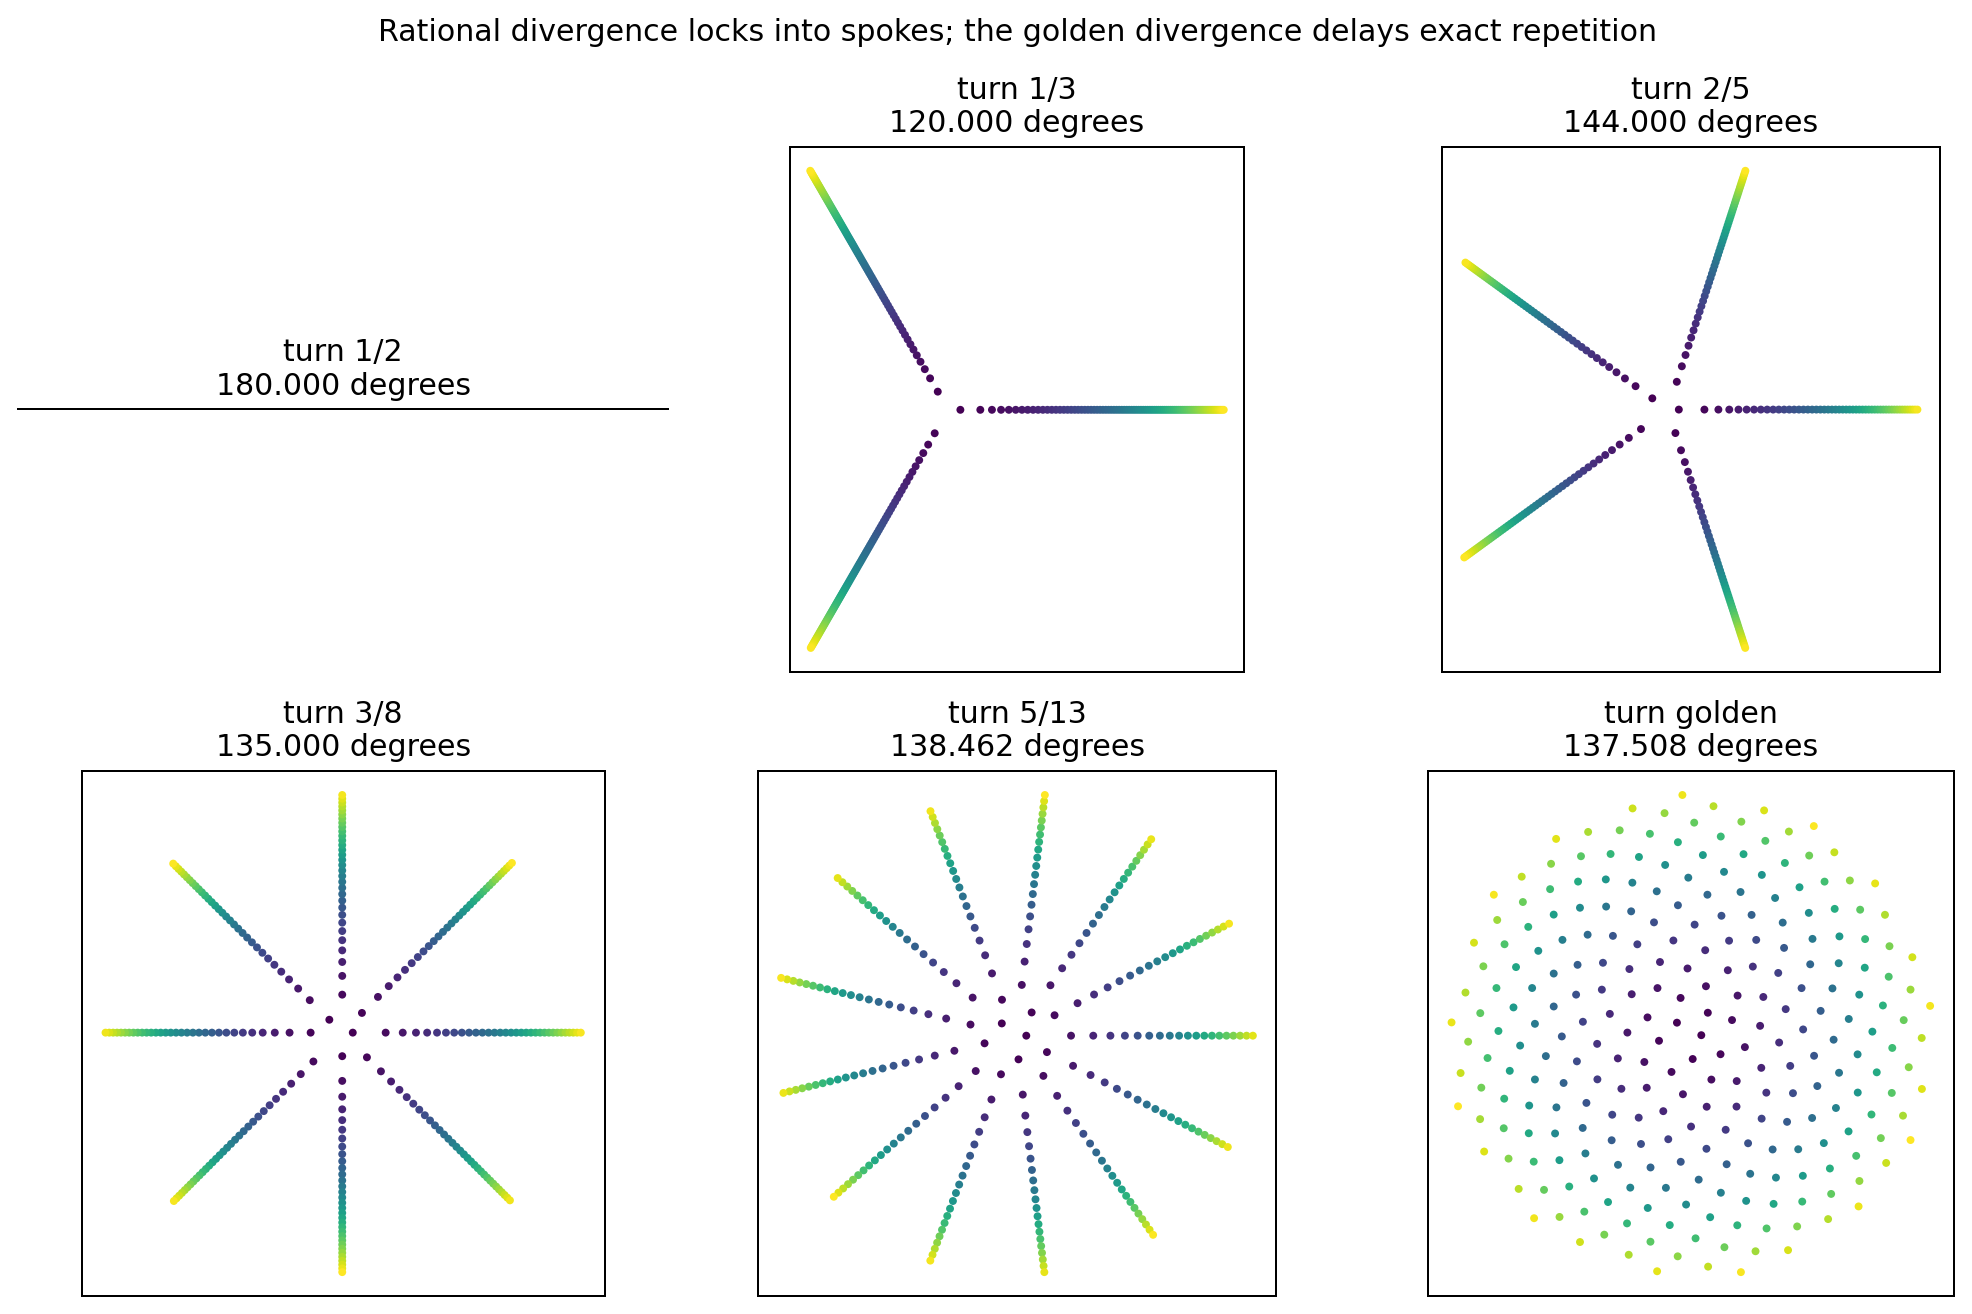

Approximant table: `artifacts/chapter-11/tables/divergence-angle-fibonacci-approximants.csv`  

Check file: `artifacts/chapter-11/checks/phyllotaxis-divergence-invariants.json`

{'golden_turn_fraction': 0.38196601125010515,
 'golden_angle_degrees': 137.50776405003785,
 'best_return_steps_through_144': [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144],
 'expected_fibonacci_return_steps': [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144],
 'fibonacci_returns_match_expected': True,
 'last_approximant_error': -0.00014782943192331865}

In [6]:
def phyllotaxis_points(turn_fraction, count=260):
    n = np.arange(count)
    theta = 2*np.pi*n*turn_fraction
    radius = np.sqrt((n + 0.5) / count)
    return n, radius*np.cos(theta), radius*np.sin(theta)

turns = [("1/2", 1/2), ("1/3", 1/3), ("2/5", 2/5), ("3/8", 3/8), ("5/13", 5/13), ("golden", GOLDEN_TURN)]
fig, axes = plt.subplots(2, 3, figsize=(11.4, 7.4))
for ax, (name, turn) in zip(axes.ravel(), turns):
    n, x, y = phyllotaxis_points(turn)
    ax.scatter(x, y, c=n, cmap="viridis", s=10, linewidths=0)
    ax.set_title(f"turn {name}\n{360*turn:.3f} degrees")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Rational divergence locks into spokes; the golden divergence delays exact repetition", y=0.98)
fig.tight_layout()
divergence_path = save_current_figure(ARTIFACT_DIRS["figures"] / "phyllotaxis-divergence-comparison.png")

fig_lab = go.Figure()
for idx_turn, (name, turn) in enumerate(turns):
    n, x, y = phyllotaxis_points(turn, count=360)
    fig_lab.add_trace(go.Scatter(x=x, y=y, mode="markers", name=name, marker={"size": 5, "color": n, "colorscale": "Viridis", "showscale": idx_turn == len(turns)-1}, visible=(name == "golden"), hovertemplate="n=%{marker.color}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra>" + name + "</extra>"))
buttons = []
for i, (name, turn) in enumerate(turns):
    visible = [False] * len(turns)
    visible[i] = True
    buttons.append({"label": f"turn {name}", "method": "update", "args": [{"visible": visible}, {"title": f"Phyllotaxis divergence: turn {name} ({360*turn:.3f} degrees)"}]})
fig_lab.update_layout(title=f"Phyllotaxis divergence: golden turn ({GOLDEN_ANGLE_DEG:.3f} degrees)", updatemenus=[{"buttons": buttons, "direction": "down", "x": 0.02, "y": 1.08}], xaxis={"scaleanchor": "y", "visible": False}, yaxis={"visible": False}, template="plotly_white", width=720, height=720)
divergence_html_path = ARTIFACT_DIRS["html"] / "phyllotaxis-divergence-lab.html"
fig_lab.write_html(divergence_html_path, include_plotlyjs="cdn")
remember(divergence_html_path)

best_returns = []
best = 1.0
for q in range(1, 145):
    dist = abs(q*GOLDEN_TURN - round(q*GOLDEN_TURN))
    if dist < best - 1e-15:
        best = dist
        best_returns.append({"q": q, "turn_distance_to_integer": dist})
expected_prefix = [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]
actual_returns = [item["q"] for item in best_returns]
approx_rows = []
for k in range(2, 10):
    approx_rows.append({"k": k, "fraction": f"{F[k-1]}/{F[k+1]}", "value": F[k-1] / F[k+1], "error_from_golden_turn": F[k-1] / F[k+1] - GOLDEN_TURN})
approx_csv_path = remember(write_csv(ARTIFACT_DIRS["tables"] / "divergence-angle-fibonacci-approximants.csv", approx_rows))
divergence_checks = {
    "golden_turn_fraction": GOLDEN_TURN,
    "golden_angle_degrees": GOLDEN_ANGLE_DEG,
    "best_return_steps_through_144": actual_returns,
    "expected_fibonacci_return_steps": expected_prefix,
    "fibonacci_returns_match_expected": actual_returns == expected_prefix,
    "last_approximant_error": float(approx_rows[-1]["error_from_golden_turn"]),
}
divergence_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "phyllotaxis-divergence-invariants.json", divergence_checks))
assert divergence_checks["fibonacci_returns_match_expected"]
assert abs(GOLDEN_ANGLE_DEG - 137.50776405003785) < 1e-12
display_artifact(divergence_path, width=840)
display_artifact(divergence_html_path, width=760)
display(Markdown(f"Approximant table: `{rel(approx_csv_path)}`  "))
display(Markdown(f"Check file: `{rel(divergence_check_path)}`"))
divergence_checks

## 6. Phyllotaxis on an Unrolled Cylinder

The source chapter models a pineapple-like surface by cutting a cylinder and unrolling it into a strip. Point \(n\) appears at

\[
(x,y)=(\{n\tau\},nh),
\]

with the left and right edges identified. Straight rows in the strip wrap back into helices on the cylinder. For the standard height \(h=F_6^{-1}\tau^{-6}\), the shortest row offsets from a point are \(5\), \(8\), and \(13\): three consecutive Fibonacci numbers. The light gray cells below are a Voronoi/Dirichlet view of the repeated lattice; the colored line families show the parastichy directions.

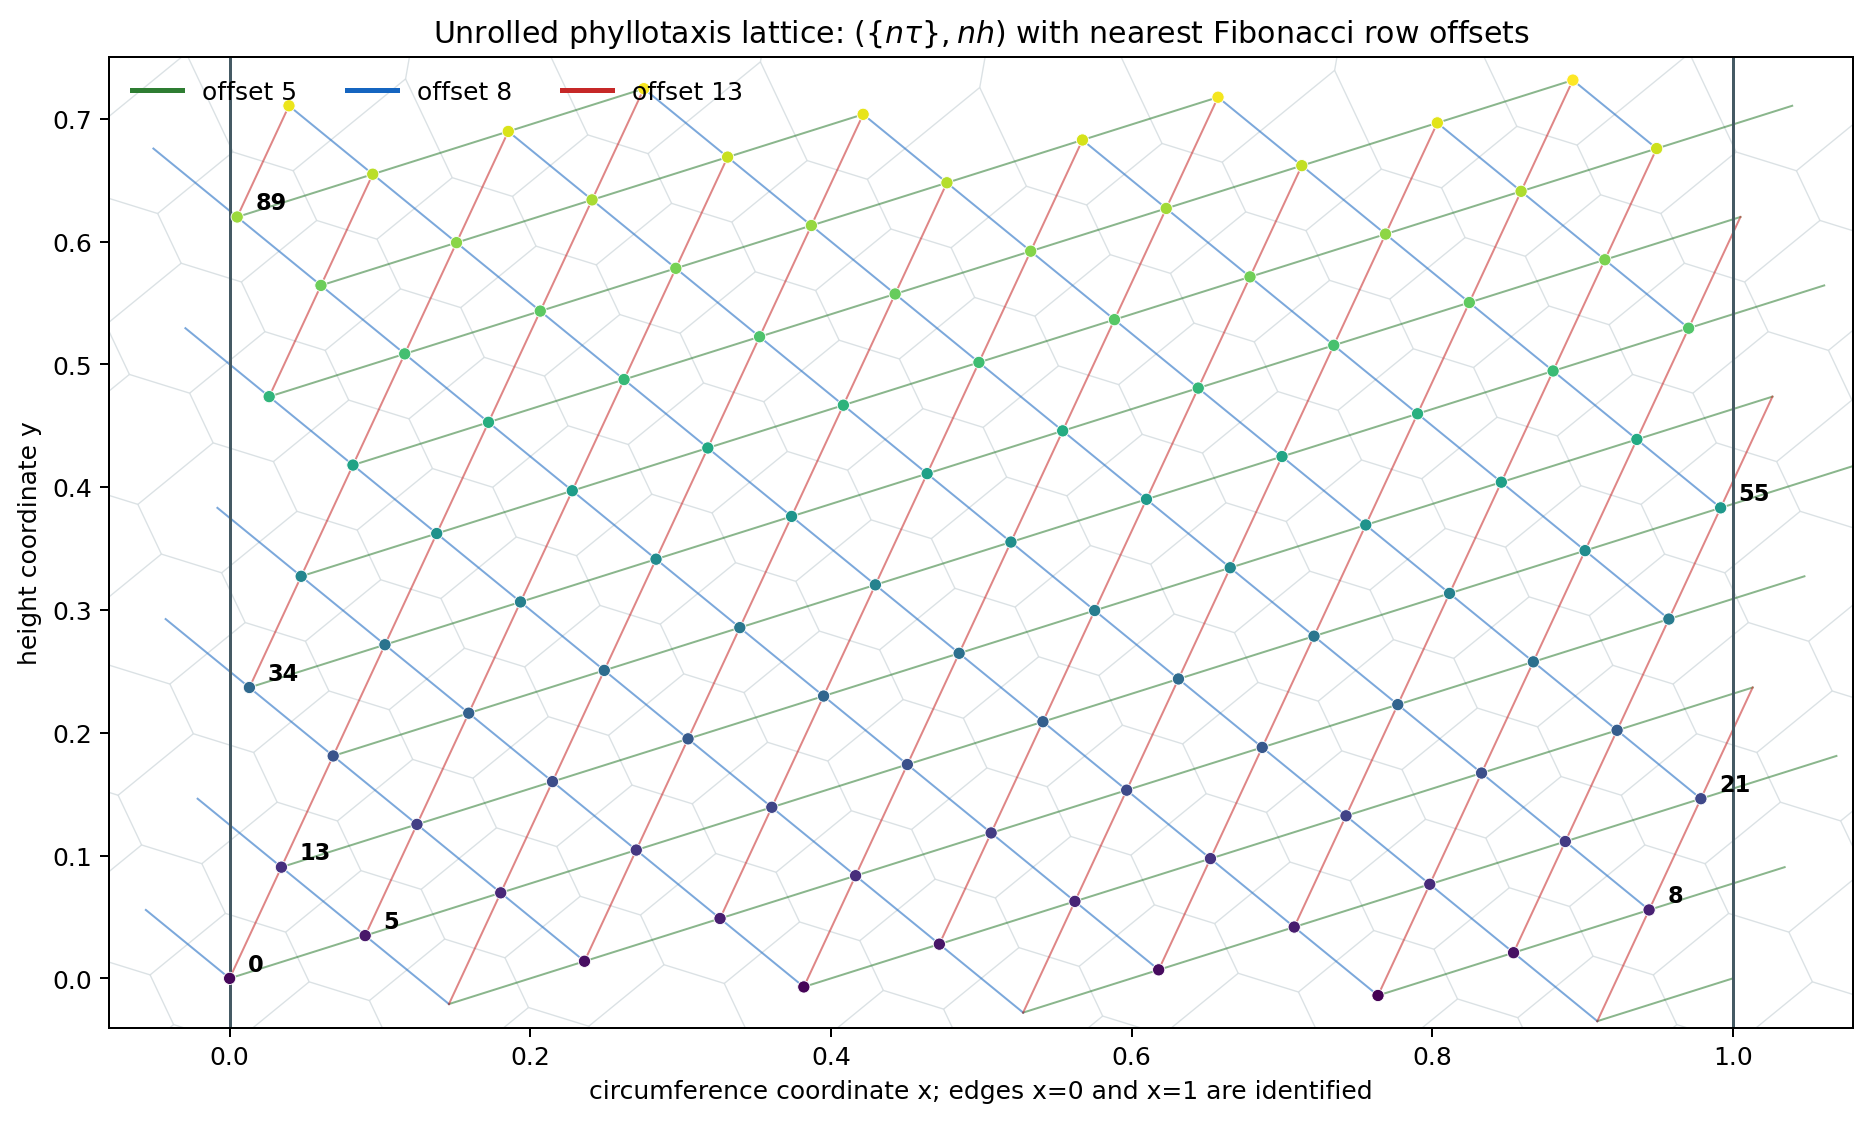

Neighbor table: `artifacts/chapter-11/tables/phyllotaxis-neighbor-distances.csv`  

Height transition sweep: `artifacts/chapter-11/tables/phyllotaxis-height-transition-sweep.csv`  

Check file: `artifacts/chapter-11/checks/phyllotaxis-cylinder-strip-invariants.json`

,offset_q,wrapped_horizontal_gap,vertical_gap,distance
7,8,0.055728,0.055728,0.078811
4,5,0.090170,0.034830,0.096663
12,13,0.034442,0.090558,0.096887
2,3,0.145898,0.020898,0.147387
20,21,0.021286,0.146286,0.147827
15,16,0.111456,0.111456,0.157623
17,18,0.124612,0.125388,0.176778
9,10,0.180340,0.069660,0.193326


In [7]:
def frac(x):
    return x - np.floor(x)

def lattice_point(n, h):
    return np.array([frac(n * TAU), n * h])

def nearest_dx(q):
    return q * TAU - round(q * TAU)

k_standard = 6
h_standard = TAU**(-k_standard) / F[k_standard]
n_min, n_max = -13, 105
base_ns = np.arange(n_min, n_max + 1)
base_points = np.array([lattice_point(n, h_standard) for n in base_ns])
rep_points = []
for shift in [-1, 0, 1]:
    for p in base_points:
        rep_points.append([p[0] + shift, p[1]])
rep_points = np.array(rep_points)
vor = Voronoi(rep_points)

fig, ax = plt.subplots(figsize=(12.5, 7.0))
segments = []
for ridge in vor.ridge_vertices:
    if -1 in ridge or len(ridge) != 2:
        continue
    a, b = vor.vertices[ridge]
    if (-0.08 <= a[0] <= 1.08 and -0.04 <= a[1] <= 0.78) or (-0.08 <= b[0] <= 1.08 and -0.04 <= b[1] <= 0.78):
        segments.append([a, b])
ax.add_collection(LineCollection(segments, colors="#cfd8dc", linewidths=0.55, alpha=0.75))

colors = {5: "#2e7d32", 8: "#1565c0", 13: "#c62828"}
for q, color in colors.items():
    dx = nearest_dx(q)
    dy = q * h_standard
    for n in range(n_min, n_max - q + 1):
        p = lattice_point(n, h_standard)
        start = np.array([p[0], p[1]])
        end = np.array([p[0] + dx, p[1] + dy])
        if -0.12 <= start[0] <= 1.12 and -0.04 <= start[1] <= 0.75 and -0.12 <= end[0] <= 1.12 and -0.04 <= end[1] <= 0.75:
            ax.plot([start[0], end[0]], [start[1], end[1]], color=color, lw=0.8, alpha=0.56)
    ax.plot([], [], color=color, lw=2, label=f"offset {q}")

visible = (base_points[:,1] >= -0.02) & (base_points[:,1] <= 0.74)
ax.scatter(base_points[visible,0], base_points[visible,1], c=base_ns[visible], cmap="viridis", s=24, edgecolors="white", linewidths=0.35, zorder=3)
for n in [0, 5, 8, 13, 21, 34, 55, 89]:
    p = lattice_point(n, h_standard)
    if -0.02 <= p[1] <= 0.74:
        ax.text(p[0] + 0.012, p[1] + 0.006, str(n), fontsize=9, weight="bold")
for xline in [0, 1]:
    ax.axvline(xline, color="#455a64", lw=1.2)
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.04, 0.75)
ax.set_xlabel("circumference coordinate x; edges x=0 and x=1 are identified")
ax.set_ylabel("height coordinate y")
ax.set_title(r"Unrolled phyllotaxis lattice: $(\{n\tau\},nh)$ with nearest Fibonacci row offsets")
ax.legend(frameon=False, loc="upper left", ncol=3)
strip_path = save_current_figure(ARTIFACT_DIRS["figures"] / "phyllotaxis-cylinder-strip-parastichies.png")

neighbor_rows = []
for q in range(1, 31):
    dx = abs(nearest_dx(q))
    dy = q * h_standard
    neighbor_rows.append({"offset_q": q, "wrapped_horizontal_gap": dx, "vertical_gap": dy, "distance": math.hypot(dx, dy)})
neighbor_df = pd.DataFrame(neighbor_rows).sort_values("distance")
neighbor_csv_path = remember(write_csv(ARTIFACT_DIRS["tables"] / "phyllotaxis-neighbor-distances.csv", neighbor_rows))

height_rows = []
for k in range(3, 10):
    h_low_boundary = (F[k] * F[k+1])**-0.5 * TAU**(-(k + 0.5))
    h_standard_k = TAU**(-k) / F[k]
    h_high_boundary = (F[k-1] * F[k])**-0.5 * TAU**(-(k - 0.5))
    height_rows.append({"k": k, "row_offsets": f"{F[k-1]}, {F[k]}, {F[k+1]}", "lower_transition_h": h_low_boundary, "standard_h": h_standard_k, "upper_transition_h": h_high_boundary, "standard_between_transitions": h_low_boundary < h_standard_k < h_high_boundary})
height_csv_path = remember(write_csv(ARTIFACT_DIRS["tables"] / "phyllotaxis-height-transition-sweep.csv", height_rows))

strip_checks = {
    "standard_k": k_standard,
    "standard_h": h_standard,
    "standard_h_matches_tau_power_over_f_k": abs(h_standard - TAU**(-6)/8) < 1e-15,
    "nearest_offsets_by_distance": [int(q) for q in neighbor_df.head(3)["offset_q"]],
    "expected_nearest_offsets_set": [5, 8, 13],
    "nearest_offsets_match_expected_set": set(neighbor_df.head(3)["offset_q"].astype(int)) == {5, 8, 13},
    "offset_8_angle_degrees": math.degrees(math.atan2(8*h_standard, abs(nearest_dx(8)))),
    "voronoi_finite_segments_plotted": len(segments),
    "height_sweep_all_standard_values_inside_transition_interval": bool(pd.DataFrame(height_rows)["standard_between_transitions"].all()),
}
strip_check_path = remember(write_json(ARTIFACT_DIRS["checks"] / "phyllotaxis-cylinder-strip-invariants.json", strip_checks))
assert strip_checks["standard_h_matches_tau_power_over_f_k"]
assert strip_checks["nearest_offsets_match_expected_set"]
assert strip_checks["voronoi_finite_segments_plotted"] > 50
assert strip_checks["height_sweep_all_standard_values_inside_transition_interval"]
display_artifact(strip_path, width=900)
display(Markdown(f"Neighbor table: `{rel(neighbor_csv_path)}`  "))
display(Markdown(f"Height transition sweep: `{rel(height_csv_path)}`  "))
display(Markdown(f"Check file: `{rel(strip_check_path)}`"))
neighbor_df.head(8)

## Proof and Invariant Scaffold

The visuals above are meant to support, not replace, the proof logic. The chapter repeatedly uses the same strategy: identify a self-similar configuration, name the quantity that survives the similarity, and then compute that quantity in a small part of the figure.

For the segment construction, the invariant is a ratio of three collinear points. Once the midpoint-square construction gives the whole length \(\tau\), the equality \(\tau=1+1/\tau\) forces the smaller added segment to be \(1/\tau\). The figure makes the construction inspectable, while the JSON check guards the exact ratio.

For the pentagon, the invariant is similarity inside the star. The outer pentagon and the inner pentagon have the same angles; a diagonal crossing cuts off a smaller copy of the same geometry. This is why checking one highlighted diagonal split is enough evidence for the whole pentagram, provided the coordinate construction has kept the regular fivefold symmetry.

For the spiral, the invariant is a fixed linear map: a quarter-turn followed by a dilation. Any point sequence generated by that map must satisfy a logarithmic relation between radius and angle. The curve is not a decorative arc; it is the continuous trace of the same multiplicative rule.

For phyllotaxis, the invariant is nearest return modulo one. Fibonacci offsets are selected because \(q\tau\) is unusually close to an integer for \(q=F_k\). The cylinder height then decides which of those near-horizontal returns are short enough to become visible rows.

## Applied Lab: Change the Turn or the Height

Two parameters control most of the visible behavior.

First, change the disk divergence fraction in the Plotly lab. Rational fractions create spokes because exact angular repetitions occur. The golden divergence keeps replacing exact repetition with near-repetitions at Fibonacci offsets.

Second, inspect the height sweep CSV for the cylinder model. Increasing or decreasing \(h\) changes which row directions are shortest. The transition values occur when two consecutive Fibonacci directions become perpendicular in the strip metric. The standard choice \(h=F_k^{-1}\tau^{-k}\) lands between adjacent transition heights and makes \(F_{k-1},F_k,F_{k+1}\) the visible parastichy counts.

In [8]:
lab_summary = {
    "disk_lab_html": rel(divergence_html_path),
    "cylinder_height_sweep_csv": rel(height_csv_path),
    "recommended_disk_comparison": ["1/3", "2/5", "3/8", "5/13", "golden"],
    "recommended_cylinder_rows_for_standard_k_6": strip_checks["nearest_offsets_by_distance"],
    "interpretation": "Exact rational repetition creates spokes; the golden turn creates Fibonacci near-returns, and the cylinder height decides which near-returns are shortest in the strip metric.",
}
lab_path = remember(write_json(ARTIFACT_DIRS["checks"] / "applied-lab-summary.json", lab_summary))
display(Markdown(f"Lab summary: `{rel(lab_path)}`"))
lab_summary

Lab summary: `artifacts/chapter-11/checks/applied-lab-summary.json`

{'disk_lab_html': 'artifacts/chapter-11/html/phyllotaxis-divergence-lab.html',
 'cylinder_height_sweep_csv': 'artifacts/chapter-11/tables/phyllotaxis-height-transition-sweep.csv',
 'recommended_disk_comparison': ['1/3', '2/5', '3/8', '5/13', 'golden'],
 'recommended_cylinder_rows_for_standard_k_6': [8, 5, 13],
 'interpretation': 'Exact rational repetition creates spokes; the golden turn creates Fibonacci near-returns, and the cylinder height decides which near-returns are shortest in the strip metric.'}

## Takeaways

- The golden section is a ratio equality, not a decimal approximation. The construction cell checks both ratios that define it.
- A regular pentagon packages the same equality: diagonal/side is \(\tau\), and crossing diagonals divide one another in the golden section.
- The golden spiral is logarithmic because a constant angle step and a constant scale step are tied together by a similarity.
- Fibonacci ratios are continued-fraction convergents to \(\tau\); Lucas identities and Cassini's identity provide integer-level checks on the same recurrence.
- Phyllotaxis is not a universal law, but the golden divergence explains why Fibonacci row counts are so persistent: Fibonacci steps are the best near-returns of the golden turn.
- In the unrolled-cylinder model, the height parameter matters. For the standard value used here, the nearest row offsets are \(5,8,13\), matching the pineapple-style parastichy counts discussed in the source span.

In [9]:
visual_artifacts = [construction_path, pentagon_path, spiral_path, spiral_html_path, fib_path, divergence_path, divergence_html_path, strip_path]
check_artifacts = [source_path, storyboard_path, construction_check_path, pentagon_check_path, spiral_check_path, fib_check_path, divergence_check_path, strip_check_path, lab_path]
table_artifacts = [fib_csv_path, approx_csv_path, neighbor_csv_path, height_csv_path]

visual_summary = {
    "chapter": CHAPTER_NO,
    "title": chapter["title"],
    "source_span": source_span,
    "figures": [rel(path) for path in visual_artifacts if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".svg"}],
    "html": [rel(path) for path in visual_artifacts if path.suffix.lower() == ".html"],
    "checks": [rel(path) for path in check_artifacts],
    "tables": [rel(path) for path in table_artifacts],
    "core_invariants": {
        "tau_quadratic": abs(TAU**2 - TAU - 1) < 1e-12,
        "pentagon_diagonal_ratio": abs(pentagon_checks["diagonal_to_side_ratio"] - TAU) < 1e-12,
        "spiral_quarter_turn": spiral_checks["node_angle_step_max_deviation_from_pi_over_2"] < 1e-12,
        "fibonacci_identities": fib_checks["all_cassini_ok"] and fib_checks["all_double_index_identities_ok"],
        "golden_angle_degrees": abs(GOLDEN_ANGLE_DEG - 137.50776405003785) < 1e-12,
        "phyllotaxis_nearest_offsets": strip_checks["nearest_offsets_match_expected_set"],
    },
}
visual_summary_path = remember(write_json(ARTIFACT_DIRS["checks"] / "visual_summary.json", visual_summary))

manifest_rows = []
for path in [*visual_artifacts, *check_artifacts, *table_artifacts, visual_summary_path]:
    manifest_rows.append({"artifact": rel(path), "kind": path.parent.name, "bytes": path.stat().st_size})
manifest_path = remember(write_csv(ARTIFACT_DIRS["tables"] / "artifact_manifest.csv", manifest_rows))
all_artifacts = list(dict.fromkeys([*visual_artifacts, *check_artifacts, *table_artifacts, visual_summary_path, manifest_path]))

assert_artifacts(all_artifacts, min_bytes=100)
assert all(visual_summary["core_invariants"].values()), visual_summary["core_invariants"]
for png_path in [path for path in visual_artifacts if path.suffix.lower() == ".png"]:
    assert png_path.read_bytes()[:8] == b"\x89PNG\r\n\x1a\n"
for html_path in [path for path in visual_artifacts if path.suffix.lower() == ".html"]:
    head = html_path.read_text(encoding="utf-8", errors="ignore")[:500].lower()
    assert "<html" in head or "<div" in head

final_sanity = {
    "chapter": CHAPTER_NO,
    "artifact_count": len(all_artifacts),
    "visual_artifact_count": len(visual_artifacts),
    "all_artifacts_nonempty": True,
    "core_invariants": visual_summary["core_invariants"],
    "smallest_artifact_bytes": min(path.stat().st_size for path in all_artifacts),
    "largest_artifact_bytes": max(path.stat().st_size for path in all_artifacts),
    "manifest": rel(manifest_path),
}
final_sanity_path = remember(write_json(ARTIFACT_DIRS["checks"] / "final-sanity.json", final_sanity))
assert_artifacts([final_sanity_path], min_bytes=100)
display(Markdown(f"Final sanity file: `{rel(final_sanity_path)}`"))
final_sanity

Final sanity file: `artifacts/chapter-11/checks/final-sanity.json`

{'chapter': 11,
 'artifact_count': 23,
 'visual_artifact_count': 8,
 'all_artifacts_nonempty': True,
 'core_invariants': {'tau_quadratic': True,
  'pentagon_diagonal_ratio': True,
  'spiral_quarter_turn': True,
  'fibonacci_identities': True,
  'golden_angle_degrees': True,
  'phyllotaxis_nearest_offsets': True},
 'smallest_artifact_bytes': 305,
 'largest_artifact_bytes': 596420,
 'manifest': 'artifacts/chapter-11/tables/artifact_manifest.csv'}